# 06 – Model Testing: Radiance Prediction Demo

Fits a LightGBM model on older radiance / impervious-surface data for
**North Carolina** and **Utah**, then predicts radiance at a later date
and maps the county-level net mismatch between the prediction and
observed later radiance.

**Edit the configuration cell below** to point at your data and set the
date labels that will appear in figure titles.

In [42]:
# =====================================================================
# CONFIGURATION – update to match your data before running
# =====================================================================

# Human-readable labels used in figure titles.
# They do NOT need to match the actual filenames; they are purely cosmetic.
OLDER_DATE = "2016"
LATER_DATE = "2021"

# Spatial neighbourhood window fed to the model (must be odd)
WINDOW_SIZE = 3

In [43]:
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from rasterio.enums import Resampling
from numpy.lib.stride_tricks import sliding_window_view
from geocube.api.core import make_geocube
import config
from diffusion import calculate_alr_for_region, calculate_alr

# ── Paths (driven by config.py) ──────────────────────────────────────
STATES_SHP    = config.STATES_SHP
COUNTIES_SHP  = config.COUNTIES_SHP
RADIANCE_OLDER = config.RADIANCE_OLDER
RADIANCE_LATER = config.RADIANCE_NEWER
IMPERV_OLDER   = config.IMPERV_OLDER
IMPERV_LATER   = config.IMPERV_NEWER

In [44]:
# =====================================================================
# HELPER FUNCTIONS
# =====================================================================

def load_and_match(path, target_da):
    """Clip and resample *path* raster to match the grid of *target_da*."""
    da = rioxarray.open_rasterio(path).squeeze()
    minx, miny, maxx, maxy = target_da.rio.bounds()
    da_clipped = da.rio.clip_box(minx, miny, maxx, maxy, crs=target_da.rio.crs)
    if da.rio.nodata is not None:
        da_clipped = da_clipped.where(da_clipped != da.rio.nodata)
    return da_clipped.rio.reproject_match(target_da, resampling=Resampling.average)


def create_spatial_features(data_array, window=3):
    """Convert a 2-D raster into a 2-D array of flattened spatial windows."""
    pad_size = window // 2
    filled = np.nan_to_num(data_array.values, nan=0.0)
    padded = np.pad(filled, pad_width=pad_size, mode='reflect')
    windows = sliding_window_view(padded, window_shape=(window, window))
    H, W = data_array.shape
    return windows.reshape(H * W, window * window)


def run_state_pipeline(state_name):
    """
    Full LightGBM pipeline for *state_name*.

    Steps
    -----
    1. Load older VIIRS radiance clipped to the state.
    2. Load and resample older + later impervious surfaces.
    3. Train LightGBM on (older impervious → older radiance).
    4. Predict radiance at later date using later impervious surface.
    5. Load observed later VIIRS radiance.
    6. Compute pixel-level mismatch = predicted_later − observed_later.

    Returns
    -------
    mismatch_da : xarray.DataArray
        Pixel-level (predicted later − observed later) radiance.
    viirs_later_da : xarray.DataArray
        Observed later radiance clipped to the state.
    viirs_older_da : xarray.DataArray
        Observed older radiance clipped to the state.
    pred_later_da : xarray.DataArray
        Model-predicted later radiance (state bbox, native VIIRS CRS).
    state_gdf : geopandas.GeoDataFrame
        State polygon in the raster CRS.
    """
    print(f"\n{'='*60}")
    print(f"  Running pipeline: {state_name}")
    print(f"{'='*60}")

    # ------------------------------------------------------------------
    # 1. Load older VIIRS and clip to state
    # ------------------------------------------------------------------
    print(f"[{state_name}] Loading older ({OLDER_DATE}) VIIRS radiance...")
    viirs_older_da = rioxarray.open_rasterio(RADIANCE_OLDER).squeeze()
    if viirs_older_da.rio.nodata is not None:
        viirs_older_da = viirs_older_da.where(viirs_older_da != viirs_older_da.rio.nodata)

    states_gdf = gpd.read_file(STATES_SHP)
    state_gdf = states_gdf[states_gdf['NAME'] == state_name].to_crs(viirs_older_da.rio.crs)
    if state_gdf.empty:
        raise ValueError(f"State '{state_name}' not found in {STATES_SHP}")

    minx, miny, maxx, maxy = state_gdf.total_bounds
    viirs_older_da = viirs_older_da.rio.clip_box(minx, miny, maxx, maxy)
    viirs_older_da.load()
    print(f"[{state_name}] Older grid shape: {viirs_older_da.shape}")

    # ------------------------------------------------------------------
    # 2. Build a strict within-state mask
    # ------------------------------------------------------------------
    state_gdf = state_gdf.copy()
    state_gdf['STATEFP_int'] = state_gdf['STATEFP'].astype(int)
    state_mask_da = make_geocube(
        vector_data=state_gdf,
        measurements=['STATEFP_int'],
        like=viirs_older_da,
        fill=0,
    ).STATEFP_int
    master_mask = (state_mask_da > 0).values

    # ------------------------------------------------------------------
    # 3. Load and resample impervious surfaces
    # ------------------------------------------------------------------
    print(f"[{state_name}] Loading impervious surfaces...")
    imp_older_da = load_and_match(IMPERV_OLDER, viirs_older_da)
    imp_later_da = load_and_match(IMPERV_LATER, viirs_older_da)

    # ------------------------------------------------------------------
    # 4. Build training dataset
    # ------------------------------------------------------------------
    valid_mask_2d = (
        master_mask
        & ~np.isnan(viirs_older_da.values)
        & ~np.isnan(imp_older_da.values)
    )
    valid_mask_1d = valid_mask_2d.flatten()

    X_older = create_spatial_features(imp_older_da, WINDOW_SIZE)
    y_older = viirs_older_da.values.flatten()
    X_train = X_older[valid_mask_1d]
    y_train = y_older[valid_mask_1d]
    print(f"[{state_name}] Training set: {X_train.shape[0]:,} pixels, "
          f"{X_train.shape[1]} features")

    # ------------------------------------------------------------------
    # 5. Train LightGBM
    # ------------------------------------------------------------------
    print(f"[{state_name}] Training LightGBM...")
    model = lgb.LGBMRegressor(
        n_estimators=100,
        max_depth=15,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)

    # ------------------------------------------------------------------
    # 6. Predict radiance at later date
    # ------------------------------------------------------------------
    # ------------------------------------------------------------------
    # 6. Predict radiance at later date & GRANDFATHER (Blend)
    # ------------------------------------------------------------------
    print(f"[{state_name}] Predicting radiance at later date ({LATER_DATE})...")
    X_later = create_spatial_features(imp_later_da, WINDOW_SIZE)
    
    # 1. Generate the raw LightGBM prediction for the entire grid
    raw_pred_later_2d = model.predict(X_later).reshape(viirs_older_da.shape)

    # 2. Create the Change Mask 
    # (Using +0.5 to ignore microscopic floating-point noise between NLCD years)
    change_mask = (imp_later_da.values > imp_older_da.values + 0.5)

    # 3. Grandfathering (The Blend)
    # np.where(Condition, True (use prediction), False (use older observed))
    blended_pred_2d = np.where(
        change_mask, 
        raw_pred_later_2d, 
        viirs_older_da.values
    )

    # 4. Apply the master state mask to keep out-of-bounds areas as NaN
    pred_later_2d = np.where(master_mask, blended_pred_2d, np.nan)

    # 5. Package back into Xarray safely
    pred_later_da = xr.DataArray(
        pred_later_2d,
        coords=viirs_older_da.coords,
        dims=viirs_older_da.dims,
    )
    pred_later_da.rio.write_crs(viirs_older_da.rio.crs, inplace=True)

    # ------------------------------------------------------------------
    # 7. Load observed later VIIRS
    # ------------------------------------------------------------------
    print(f"[{state_name}] Loading observed later ({LATER_DATE}) VIIRS radiance...")
    viirs_later_da = rioxarray.open_rasterio(RADIANCE_LATER).squeeze()
    if viirs_later_da.rio.nodata is not None:
        viirs_later_da = viirs_later_da.where(viirs_later_da != viirs_later_da.rio.nodata)
    viirs_later_da = viirs_later_da.rio.clip_box(minx, miny, maxx, maxy)
    viirs_later_da = viirs_later_da.rio.reproject_match(viirs_older_da)
    viirs_later_da = viirs_later_da.where(master_mask)

    # ------------------------------------------------------------------
    # 8. Compute mismatch: predicted_later − observed_later
    # ------------------------------------------------------------------
    mismatch_da = pred_later_da - viirs_later_da

    print(f"[{state_name}] Pipeline complete.")
    return mismatch_da, viirs_later_da, viirs_older_da, pred_later_da, state_gdf

In [45]:
def plot_county_choropleth(mismatch_da, state_name, counties_shp, state_fips, title=None):
    """
    Aggregate pixel-level mismatch to county polygons and plot a choropleth.

    Parameters
    ----------
    mismatch_da : xarray.DataArray
        Pixel-level (predicted_later − observed_later) radiance.
    state_name : str
        Human-readable state name (used in the default title).
    counties_shp : path-like
        Path to the US counties shapefile.
    state_fips : str
        Two-digit state FIPS code string (e.g. '37' for NC, '49' for UT).
    title : str or None
        Override the auto-generated figure title.

    Returns
    -------
    geopandas.GeoDataFrame
        Counties with a 'mean_mismatch' column added.
    """
    if title is None:
        title = (
            f"{state_name}: Net Radiance Mismatch by County\n"
            f"(Predicted {LATER_DATE} − Observed {LATER_DATE}, nW/cm²/sr)"
        )

    # Load counties for this state
    counties = gpd.read_file(counties_shp)
    state_counties = counties[counties['STATEFP'] == state_fips].copy()
    state_counties = state_counties.to_crs(mismatch_da.rio.crs)

    # Rasterize county integer FIPS onto the mismatch grid
    state_counties['COUNTYFP_int'] = state_counties['COUNTYFP'].astype(int)
    county_id_da = make_geocube(
        vector_data=state_counties,
        measurements=['COUNTYFP_int'],
        like=mismatch_da,
        fill=0,
    ).COUNTYFP_int

    # Compute mean mismatch per county
    county_ids = county_id_da.values.flatten()
    mismatch_vals = mismatch_da.values.flatten()

    county_means = {}
    for fips_int in state_counties['COUNTYFP_int'].unique():
        mask = (county_ids == fips_int) & np.isfinite(mismatch_vals)
        county_means[fips_int] = mismatch_vals[mask].mean() if mask.sum() > 0 else np.nan

    state_counties['mean_mismatch'] = state_counties['COUNTYFP_int'].map(county_means)

    # Symmetric colour scale centred on zero
    abs_max = state_counties['mean_mismatch'].abs().max()

    fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
    state_counties.plot(
        column='mean_mismatch',
        ax=ax,
        cmap='coolwarm',
        vmin=-abs_max,
        vmax=abs_max,
        legend=True,
        legend_kwds={'label': 'Mean mismatch (nW/cm²/sr)', 'shrink': 0.7},
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        edgecolor='black',
        linewidth=0.3,
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    return state_counties

In [46]:
def print_mismatch_summary(mismatch_da, viirs_later_da, state_name, n=5):
    """
    Print a radiance mismatch summary and the top-n most positive and
    negative pixel locations (in the raster's native CRS) for *state_name*.
    """
    obs_total = float(viirs_later_da.sum().values)
    net_error = float(mismatch_da.sum().values)
    mae       = float(np.abs(mismatch_da).mean().values)

    print(f"=== {state_name} – Radiance Mismatch ({LATER_DATE}) ===")
    print(f"Total Observed Sum of Lights : {obs_total:>15,.2f} nW/cm²/sr")
    print(f"Net Mismatch (Predicted−Obs) : {net_error:>+15,.2f} nW/cm²/sr "
          f"({net_error / obs_total * 100:+.2f}%)")
    print(f"Mean Absolute Error per pixel: {mae:>15.3f} nW/cm²/sr")

    df = (
        mismatch_da
        .to_dataframe(name='mismatch')
        .reset_index()
        .dropna(subset=['mismatch'])
        .rename(columns={'x': 'lon', 'y': 'lat'})
        [['lat', 'lon', 'mismatch']]
    )

    print(f"\n  Top {n} Most POSITIVE pixels (Predicted > Observed):")
    print(df.nlargest(n, 'mismatch').reset_index(drop=True)
            .to_string(index=False, float_format='{:+.4f}'.format))

    print(f"\n  Top {n} Most NEGATIVE pixels (Predicted < Observed):")
    print(df.nsmallest(n, 'mismatch').reset_index(drop=True)
            .to_string(index=False, float_format='{:+.4f}'.format))


In [47]:
def plot_biggest_mismatch_co(mismatch_da, counties_gdf, state_name):
    """
    Find the county with the largest absolute mean mismatch, clip
    mismatch_da to that county polygon, and plot the pixel-level raster.

    Parameters
    ----------
    mismatch_da : xarray.DataArray
        Pixel-level (predicted_later − observed_later) radiance with CRS.
    counties_gdf : geopandas.GeoDataFrame
        Output of plot_county_choropleth – must contain 'NAME' and
        'mean_mismatch' columns.
    state_name : str
        Used in the figure title.
    """
    # Identify county with the largest absolute mean mismatch
    worst_idx = counties_gdf['mean_mismatch'].abs().idxmax()
    worst_county = counties_gdf.loc[[worst_idx]].copy()
    county_name = worst_county['NAME'].values[0]
    county_mean = worst_county['mean_mismatch'].values[0]

    # Align CRS with the raster
    if worst_county.crs != mismatch_da.rio.crs:
        worst_county = worst_county.to_crs(mismatch_da.rio.crs)

    # Clip raster to county boundary
    clipped = mismatch_da.rio.clip(worst_county.geometry, worst_county.crs, drop=True)

    # Symmetric colour scale centred on zero
    abs_max = float(np.abs(clipped).max())

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    clipped.plot(
        ax=ax,
        cmap='coolwarm',
        vmin=-abs_max,
        vmax=abs_max,
        cbar_kwargs={'label': 'Mismatch (nW/cm²/sr)', 'shrink': 0.8},
    )
    worst_county.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)
    ax.set_title(
        f"{state_name} – {county_name} County (largest |mismatch|)\n"
        f"Predicted {LATER_DATE} − Observed {LATER_DATE}  "
        f"(county mean = {county_mean:+.2f} nW/cm²/sr)",
        fontsize=12, fontweight='bold',
    )
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


---
## Sky Quality Analysis – Duriscoe et al. ALR Classification

This section computes the **All-sky Light-pollution Ratio (ALR)** for three
radiance layers per state and classifies each pixel into one of four sky
quality bands following Duriscoe et al. (2018):

| Class | ALR range |
|---|---|
| Good | 0 – 0.33 |
| Moderate (threatened) | 0.33 – 2 |
| Poor (sensitive protected areas) | 2 – 10 |
| Milky Way invisible | > 10 |

Three comparisons are produced for each state:
1. **Sky quality maps** – actual older / predicted later / actual later
2. **Mismatch map** – where the model prediction over/under-estimates future
   sky quality relative to observed later data
3. **Actual degradation map** – where actual sky quality worsened from the
   older to the later period (point of comparison)

> ⚠️  Each ALR run takes several minutes.  Three runs per state × 3 states
> ≈ 30–45 min total.  Consider caching results for interactive re-use.


In [ ]:
# =====================================================================
# SKY QUALITY ANALYSIS – Duriscoe et al. ALR Classification
# =====================================================================

# EPSG:5070 = CONUS Albers Equal Area (metres)
_SQ_ALBERS_EPSG = 5070

# ALR thresholds and display attributes from Duriscoe et al. (2018)
ALR_BINS  = [0, 0.33, 2.0, 10.0, np.inf]
SQ_LABELS = [
    "Good (0–0.33)",
    "Moderate (0.33–2)",
    "Poor (2–10)",
    "Milky Way invisible (>10)",
]
SQ_SHORT  = ["Good", "Moderate", "Poor", "Milky Way invisible"]
SQ_COLORS = ["#1a9641", "#fdae61", "#d7191c", "#7b2d8b"]
SQ_CMAP   = mcolors.ListedColormap(SQ_COLORS)
SQ_NORM   = mcolors.BoundaryNorm([0, 1, 2, 3, 4], SQ_CMAP.N)


def classify_sky_quality(alr_arr: np.ndarray) -> np.ndarray:
    """Map ALR values → integer class (0=Good … 3=MW invisible).

    Parameters
    ----------
    alr_arr : 2-D float array with NaN where no data.

    Returns
    -------
    classified : float array, same shape, NaN preserved.
    """
    classified = (np.digitize(alr_arr, ALR_BINS) - 1).astype(float)
    classified[np.isnan(alr_arr)] = np.nan
    return classified


In [ ]:
def _build_composite_da(pred_later_da, state_gdf, viirs_later_path,
                        albers_epsg=_SQ_ALBERS_EPSG, target_res_m=450.0):
    """Reproject predictions to Albers, embed in global VIIRS-later background.

    Returns a buffered (300 km) Albers DataArray whose interior pixels come
    from the model predictions and whose outer-buffer pixels come from the
    observed later VIIRS.  This gives ALR a realistic 300-km neighbourhood
    without propagating NaN-padded edges.
    """
    # --- Build buffered ROI in Albers ---
    region_albers = state_gdf.to_crs(epsg=albers_epsg)
    buffer_geom   = region_albers.union_all().buffer(300_000)
    buffer_gdf    = gpd.GeoDataFrame(geometry=[buffer_geom], crs=region_albers.crs)

    # --- Clip and reproject global VIIRS-later to Albers buffer ---
    viirs_global = rioxarray.open_rasterio(viirs_later_path, masked=True).squeeze()
    buffer_src   = buffer_gdf.to_crs(viirs_global.rio.crs)
    minx, miny, maxx, maxy = buffer_src.total_bounds
    viirs_clip   = viirs_global.rio.clip_box(minx, miny, maxx, maxy)
    viirs_albers = viirs_clip.rio.reproject(
        f"EPSG:{albers_epsg}", resolution=target_res_m, nodata=np.nan
    )
    viirs_buf = viirs_albers.rio.clip(buffer_gdf.geometry, all_touched=True, drop=True)

    # --- Reproject predictions onto the same Albers grid ---
    pred_albers = pred_later_da.rio.reproject_match(viirs_buf, nodata=np.nan)

    # --- Composite: use predictions where defined, VIIRS-later elsewhere ---
    pred_arr   = pred_albers.values.squeeze()
    viirs_arr  = viirs_buf.values.squeeze()
    composite  = np.where(~np.isnan(pred_arr), pred_arr, viirs_arr)
    comp_da    = viirs_buf.copy(data=composite[np.newaxis] if viirs_buf.ndim == 3 else composite)

    return comp_da, region_albers


def compute_alr_observed(viirs_path, state_gdf,
                         albers_epsg=_SQ_ALBERS_EPSG, target_res_m=450.0, n_rings=38):
    """Compute ALR from a global VIIRS raster for one state.

    Uses a full 300-km buffer, so edge-pixel ALR is accurate.

    Returns
    -------
    xarray.DataArray
        ALR clipped to *state_gdf*, in EPSG:*albers_epsg*.
    """
    viirs_da = rioxarray.open_rasterio(viirs_path, masked=True).squeeze()
    return calculate_alr_for_region(
        viirs_da=viirs_da,
        region_gdf=state_gdf,
        albers_epsg=albers_epsg,
        target_res_m=target_res_m,
        n_rings=n_rings,
    )


def compute_alr_predicted(pred_later_da, state_gdf, viirs_later_path,
                          albers_epsg=_SQ_ALBERS_EPSG, target_res_m=450.0, n_rings=38):
    """Compute ALR for the model predictions.

    Builds a composite (predictions inside state, observed VIIRS-later outside)
    so the full 300-km buffer contributes to each pixel's ALR.

    Returns
    -------
    xarray.DataArray
        ALR clipped to *state_gdf*, in EPSG:*albers_epsg*.
    """
    comp_da, region_albers = _build_composite_da(
        pred_later_da, state_gdf, viirs_later_path,
        albers_epsg=albers_epsg, target_res_m=target_res_m,
    )

    pixel_size_km = target_res_m / 1000.0
    arr = comp_da.values.squeeze().astype(float)
    arr[arr < 0] = np.nan

    alr_arr = calculate_alr(arr, pixel_size_km=pixel_size_km, n_rings=n_rings)

    alr_da = comp_da.copy(data=alr_arr[np.newaxis] if comp_da.ndim == 3 else alr_arr)
    alr_da.attrs["long_name"] = "ALR – Predicted later"

    return alr_da.rio.clip(region_albers.geometry, all_touched=True, drop=True)


In [ ]:
# ── Colour scheme for transition / mismatch maps ─────────────────────────────
#
#  -3  to -1  : improvement   (lighter < darker greens)
#   0          : no change     (light grey)
#  +1 to +3   : degradation   (yellows → reds)
#
_TRANS_BOUNDS = [-3, -2, -1, 0, 1, 2, 3, 4]  # BoundaryNorm edges
_TRANS_COLORS = [
    "#1a6930",   # -3  strong improvement (3 classes better)
    "#52ae61",   # -2  improvement 2 classes
    "#b2e0a4",   # -1  improvement 1 class
    "#d9d9d9",   #  0  no change
    "#fee08b",   # +1  1-class degradation
    "#f46d43",   # +2  2-class degradation
    "#a50026",   # +3  3-class degradation
]
_TRANS_CMAP = mcolors.ListedColormap(_TRANS_COLORS)
_TRANS_NORM = mcolors.BoundaryNorm(_TRANS_BOUNDS, _TRANS_CMAP.N)


def _transition_arr(class_before: np.ndarray, class_after: np.ndarray) -> np.ndarray:
    """Pixel-level class change: after – before  (positive = degradation)."""
    diff = class_after - class_before
    diff[np.isnan(class_before) | np.isnan(class_after)] = np.nan
    return diff


def _sq_legend_patches():
    """Matplotlib patch handles for the 4-class sky-quality legend."""
    import matplotlib.patches as mpatches
    return [
        mpatches.Patch(color=c, label=l)
        for c, l in zip(SQ_COLORS, SQ_LABELS)
    ]


def _trans_legend_patches():
    """Matplotlib patch handles for the 7-bin transition legend."""
    import matplotlib.patches as mpatches
    trans_labels = [
        "Improved 3 classes", "Improved 2 classes", "Improved 1 class",
        "No change",
        "Degraded 1 class", "Degraded 2 classes", "Degraded 3 classes",
    ]
    return [
        mpatches.Patch(color=c, label=l)
        for c, l in zip(_TRANS_COLORS, trans_labels)
    ]


def plot_sky_quality_maps(sq_older, sq_predicted, sq_later, state_name,
                          older_label=None, later_label=None):
    """Three-panel sky quality map: actual older | predicted later | actual later.

    Parameters
    ----------
    sq_older, sq_predicted, sq_later : 2-D float arrays (class 0–3 or NaN)
    state_name : str
    older_label, later_label : cosmetic year strings
    """
    older_label  = older_label  or OLDER_DATE
    later_label  = later_label  or LATER_DATE

    titles = [
        f"Actual {older_label}\nSky Quality",
        f"Predicted {later_label}\nSky Quality",
        f"Actual {later_label}\nSky Quality",
    ]
    arrs = [sq_older, sq_predicted, sq_later]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=130)
    for ax, arr, title in zip(axes, arrs, titles):
        ax.imshow(arr, cmap=SQ_CMAP, norm=SQ_NORM, origin="upper",
                  interpolation="nearest")
        ax.set_title(title, fontsize=11)
        ax.axis("off")

    handles = _sq_legend_patches()
    fig.legend(handles=handles, loc="lower center", ncol=4,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(
        f"{state_name} – Sky Quality Classification (Duriscoe et al.)",
        fontsize=14, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.show()


def plot_sky_quality_transition(trans_arr, state_name, title_suffix,
                                focus_degradation=True):
    """Single-panel map showing sky quality class transitions.

    Parameters
    ----------
    trans_arr : 2-D float array from _transition_arr()
    state_name : str
    title_suffix : str  (e.g. "Predicted vs Actual Later")
    focus_degradation : bool
        When True, also prints the pixel fraction that degraded.
    """
    fig, ax = plt.subplots(figsize=(10, 7), dpi=130)
    img = ax.imshow(trans_arr, cmap=_TRANS_CMAP, norm=_TRANS_NORM,
                    origin="upper", interpolation="nearest")
    ax.set_title(
        f"{state_name} – Sky Quality Transitions\n{title_suffix}",
        fontsize=13, fontweight="bold",
    )
    ax.axis("off")

    handles = _trans_legend_patches()
    ax.legend(handles=handles, loc="lower right", fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()

    if focus_degradation:
        valid = trans_arr[~np.isnan(trans_arr)]
        degrade = (valid > 0).sum()
        improve = (valid < 0).sum()
        same    = (valid == 0).sum()
        total   = len(valid)
        print(f"  Degraded : {degrade:>7,} px ({100*degrade/total:.1f}%)")
        print(f"  No change: {same:>7,} px ({100*same/total:.1f}%)")
        print(f"  Improved : {improve:>7,} px ({100*improve/total:.1f}%)")


def print_transition_matrix(class_before, class_after, label_before, label_after, state_name):
    """Print a cross-tabulation of sky quality class transitions.

    Rows = class_before, Cols = class_after, values = % of valid pixels.
    """
    valid = ~np.isnan(class_before) & ~np.isnan(class_after)
    b = class_before[valid].astype(int)
    a = class_after[valid].astype(int)
    total = len(b)

    n = len(SQ_SHORT)
    mat = np.zeros((n, n), dtype=int)
    for bi, ai in zip(b, a):
        if 0 <= bi < n and 0 <= ai < n:
            mat[bi, ai] += 1

    print(f"\n{'='*64}")
    print(f"  {state_name}: Sky Quality Transition Matrix")
    print(f"  {label_before} → {label_after}  (rows=before, cols=after, values=% of pixels)")
    print(f"{'='*64}")

    col_w = 12
    header = f"{'':20s}" + "".join(f"{s:>{col_w}s}" for s in SQ_SHORT)
    print(header)
    print("-" * (20 + n * col_w))

    for i, row_label in enumerate(SQ_SHORT):
        row_str = f"{row_label:<20s}"
        for j in range(n):
            pct = 100.0 * mat[i, j] / total if total > 0 else 0.0
            row_str += f"{pct:>{col_w}.1f}%"
        print(row_str)

    total_degraded = 0
    for i in range(n):
        for j in range(i + 1, n):   # j > i means class number got higher = degraded
            total_degraded += mat[i, j]
    print(f"\n  Total degraded  : {total_degraded:,} px  "
          f"({100.0*total_degraded/total:.1f}%  of valid pixels)")
    # Highlight key transitions
    key = [(0,1,"Good→Moderate"), (0,2,"Good→Poor"), (0,3,"Good→MW invisible"),
           (1,2,"Moderate→Poor"), (1,3,"Moderate→MW invisible"), (2,3,"Poor→MW invisible")]
    for i,j,lbl in key:
        if mat[i,j] > 0:
            print(f"    {lbl}: {mat[i,j]:,} px  ({100.0*mat[i,j]/total:.2f}%)")


In [ ]:
def run_sky_quality_analysis(
    state_name,
    viirs_older_da,
    pred_later_da,
    viirs_later_da,
    state_gdf,
    n_rings=38,
):
    """Compute ALR for all three radiance layers and produce sky quality plots.

    Parameters
    ----------
    state_name : str
    viirs_older_da : DataArray  – observed older radiance (state bbox, native CRS)
    pred_later_da  : DataArray  – predicted later radiance (state bbox, native CRS)
    viirs_later_da : DataArray  – observed later radiance (state bbox, native CRS)
    state_gdf : GeoDataFrame    – state boundary in raster CRS
    n_rings : int               – number of ALR annular rings (default 38)

    Returns
    -------
    dict with keys: alr_older, alr_predicted, alr_later,
                    sq_older, sq_predicted, sq_later
    """
    import time

    print(f"\n{'='*60}")
    print(f"  Sky Quality Analysis: {state_name}")
    print(f"{'='*60}")

    # ------------------------------------------------------------------
    # ALR for observed older
    # ------------------------------------------------------------------
    print(f"[{state_name}] Computing ALR – observed {OLDER_DATE}  (may take several min)…")
    t0 = time.time()
    alr_older_da = compute_alr_observed(
        RADIANCE_OLDER, state_gdf, n_rings=n_rings
    )
    print(f"  done in {time.time()-t0:.0f} s")

    # ------------------------------------------------------------------
    # ALR for observed later
    # ------------------------------------------------------------------
    print(f"[{state_name}] Computing ALR – observed {LATER_DATE}  (may take several min)…")
    t0 = time.time()
    alr_later_da = compute_alr_observed(
        RADIANCE_LATER, state_gdf, n_rings=n_rings
    )
    print(f"  done in {time.time()-t0:.0f} s")

    # ------------------------------------------------------------------
    # ALR for model predictions (composite: predictions inside state,
    # VIIRS-later outside, for an accurate 300-km buffer)
    # ------------------------------------------------------------------
    print(f"[{state_name}] Computing ALR – predicted {LATER_DATE}  (may take several min)…")
    t0 = time.time()
    alr_pred_da = compute_alr_predicted(
        pred_later_da, state_gdf, RADIANCE_LATER, n_rings=n_rings
    )
    print(f"  done in {time.time()-t0:.0f} s")

    # ------------------------------------------------------------------
    # Classify to sky quality classes
    # ------------------------------------------------------------------
    # Reproject all ALR DataArrays to the same Albers grid for pixel-wise ops
    alr_pred_arr  = alr_pred_da.values.squeeze()
    alr_later_arr = alr_later_da.rio.reproject_match(alr_pred_da).values.squeeze()
    alr_older_arr = alr_older_da.rio.reproject_match(alr_pred_da).values.squeeze()

    sq_older     = classify_sky_quality(alr_older_arr)
    sq_predicted = classify_sky_quality(alr_pred_arr)
    sq_later     = classify_sky_quality(alr_later_arr)

    # ------------------------------------------------------------------
    # Plot 1: Three-panel sky quality maps
    # ------------------------------------------------------------------
    plot_sky_quality_maps(sq_older, sq_predicted, sq_later, state_name)

    # ------------------------------------------------------------------
    # Plot 2: Mismatch map – where does the prediction over/under-estimate
    #         sky quality relative to observed later?
    #         Positive = predicted better than actual (model optimistic)
    #         Negative = predicted worse than actual (model pessimistic)
    # ------------------------------------------------------------------
    # Convention: "degradation" = sky quality got WORSE (higher class number)
    # mismatch = sq_later - sq_predicted  (positive → actual is worse than pred)
    mismatch_sq = _transition_arr(sq_predicted, sq_later)

    print(f"\n[{state_name}] Sky quality mismatch (actual later vs predicted later):")
    plot_sky_quality_transition(
        mismatch_sq, state_name,
        title_suffix=(
            f"Sky Quality Mismatch: Actual {LATER_DATE} vs Predicted {LATER_DATE}\n"
            f"Positive = actual is worse than predicted (model too optimistic)"
        ),
    )
    print_transition_matrix(sq_predicted, sq_later,
                            f"Predicted {LATER_DATE}", f"Actual {LATER_DATE}",
                            state_name)

    # ------------------------------------------------------------------
    # Plot 3: Degradation map – how has actual sky quality changed from
    #         older to later period?
    # ------------------------------------------------------------------
    degrade_sq = _transition_arr(sq_older, sq_later)

    print(f"\n[{state_name}] Actual sky quality degradation ({OLDER_DATE}→{LATER_DATE}):")
    plot_sky_quality_transition(
        degrade_sq, state_name,
        title_suffix=(
            f"Actual Sky Quality Degradation: {OLDER_DATE} → {LATER_DATE}\n"
            f"Positive = sky quality has gotten worse"
        ),
    )
    print_transition_matrix(sq_older, sq_later,
                            f"Actual {OLDER_DATE}", f"Actual {LATER_DATE}",
                            state_name)

    return dict(
        alr_older=alr_older_da,
        alr_predicted=alr_pred_da,
        alr_later=alr_later_da,
        sq_older=sq_older,
        sq_predicted=sq_predicted,
        sq_later=sq_later,
    )


---
## North Carolina

In [48]:
nc_mismatch_da, nc_viirs_later_da, nc_viirs_older_da, nc_pred_later_da, nc_state_gdf = run_state_pipeline("North Carolina")


  Running pipeline: North Carolina
[North Carolina] Loading older (2016) VIIRS radiance...
[North Carolina] Older grid shape: (681, 2142)
[North Carolina] Loading impervious surfaces...
[North Carolina] Training set: 797,075 pixels, 9 features
[North Carolina] Training LightGBM...
[North Carolina] Predicting radiance at later date (2021)...


/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[North Carolina] Loading observed later (2021) VIIRS radiance...
[North Carolina] Pipeline complete.


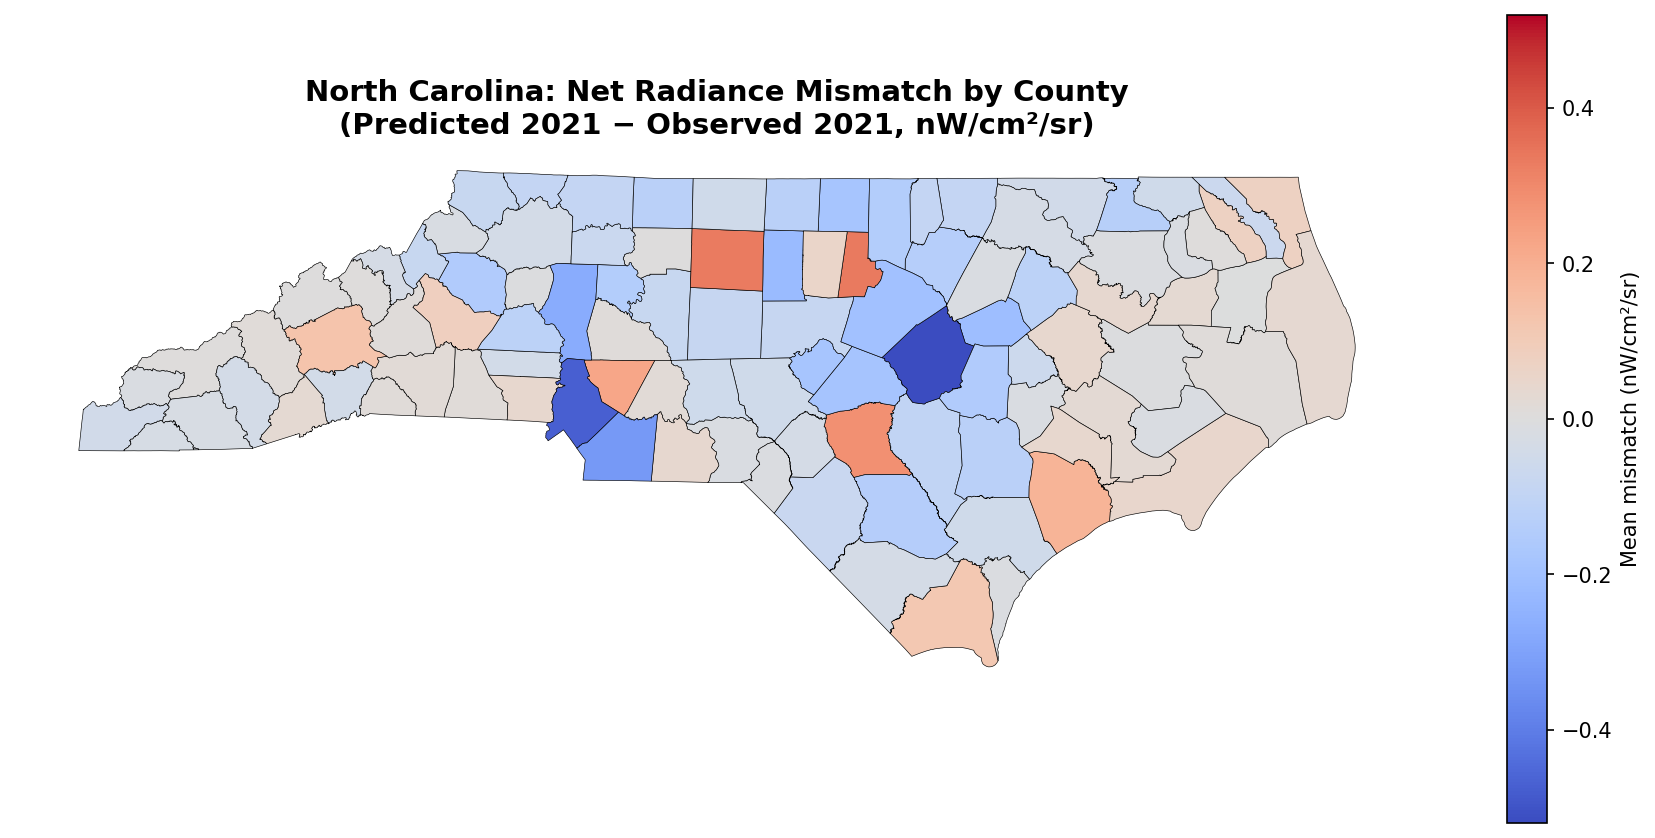

In [49]:
nc_counties = plot_county_choropleth(
    nc_mismatch_da,
    state_name="North Carolina",
    counties_shp=COUNTIES_SHP,
    state_fips='37',
)

Text(0.5, 1.0, 'Histogram of Pixel-Level Radiance Mismatch in NC')

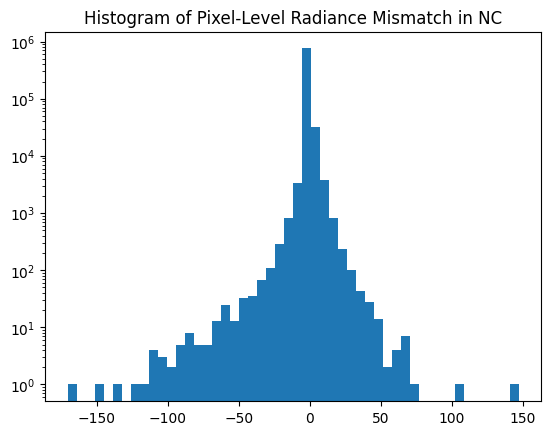

In [50]:
nc_mismatch_da.plot.hist(bins=50, log=True)
plt.title("Histogram of Pixel-Level Radiance Mismatch in NC")

In [51]:
print_mismatch_summary(nc_mismatch_da, nc_viirs_later_da, "North Carolina")


=== North Carolina – Radiance Mismatch (2021) ===
Total Observed Sum of Lights :    1,480,290.00 nW/cm²/sr
Net Mismatch (Predicted−Obs) :      -30,467.01 nW/cm²/sr (-2.06%)
Mean Absolute Error per pixel:           0.518 nW/cm²/sr

  Top 5 Most POSITIVE pixels (Predicted > Observed):
     lat      lon  mismatch
+36.3583 -76.8042 +147.1822
+36.3583 -76.8083 +107.6730
+35.8833 -81.1792  +72.5812
+35.6083 -77.4083  +70.8207
+34.1875 -78.9125  +70.1465

  Top 5 Most NEGATIVE pixels (Predicted < Observed):
     lat      lon  mismatch
+35.8875 -78.5667 -170.5029
+35.9708 -79.9958 -146.5446
+35.8875 -78.5708 -135.4134
+34.7500 -78.8042 -121.4024
+35.7792 -80.8625 -119.3059


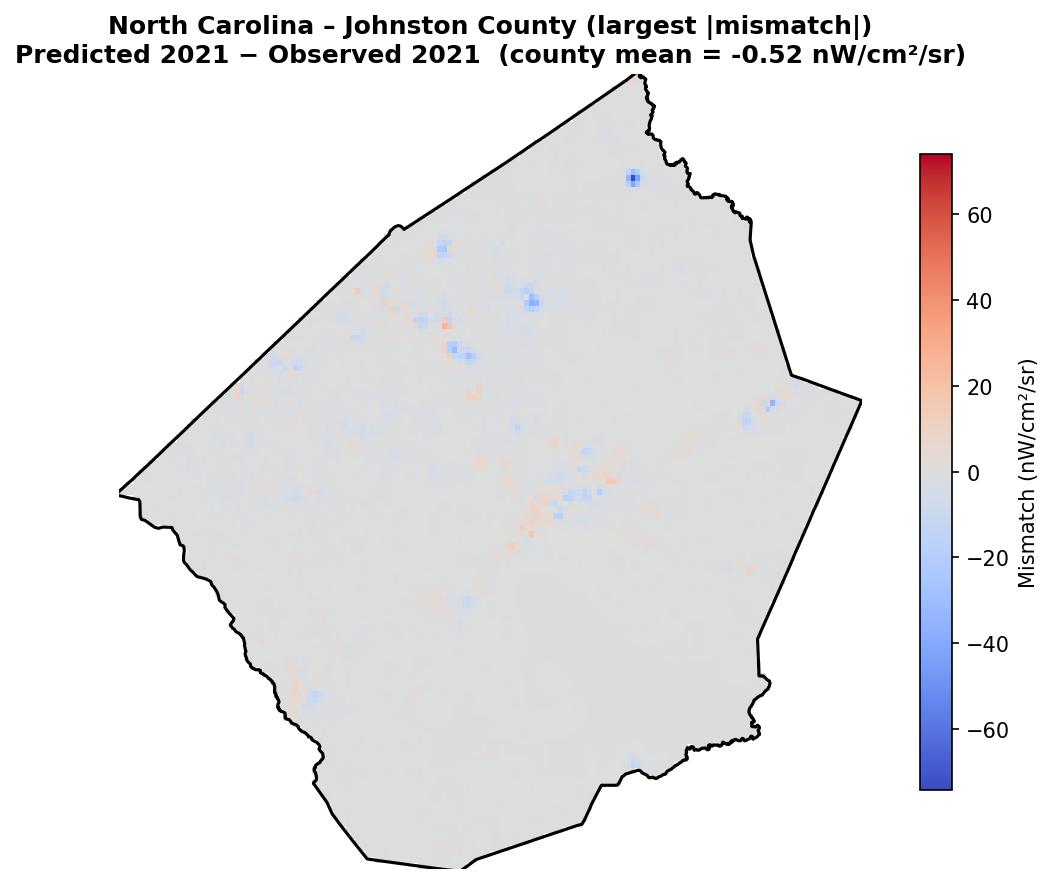

In [52]:
plot_biggest_mismatch_co(nc_mismatch_da, nc_counties, "North Carolina")

In [ ]:
nc_sq = run_sky_quality_analysis(
    "North Carolina",
    nc_viirs_older_da,
    nc_pred_later_da,
    nc_viirs_later_da,
    nc_state_gdf,
)


---
## Utah

In [53]:
ut_mismatch_da, ut_viirs_later_da, ut_viirs_older_da, ut_pred_later_da, ut_state_gdf = run_state_pipeline("Utah")


  Running pipeline: Utah
[Utah] Loading older (2016) VIIRS radiance...
[Utah] Older grid shape: (1202, 1204)
[Utah] Loading impervious surfaces...
[Utah] Training set: 1,323,139 pixels, 9 features
[Utah] Training LightGBM...
[Utah] Predicting radiance at later date (2021)...


/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[Utah] Loading observed later (2021) VIIRS radiance...
[Utah] Pipeline complete.


(array([1.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        1.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 2.000000e+00, 0.000000e+00, 0.000000e+00,
        1.000000e+00, 3.000000e+00, 5.000000e+00, 1.100000e+01,
        1.370000e+02, 1.322357e+06, 5.780000e+02, 2.700000e+01,
        6.000000e+00, 2.000000e+00, 0.000000e+00, 1.000000e+00,
        1.000000e+00, 0.000000e+00, 0.000000e+00, 1.000000e+00,
        0.000000e+00, 1.000000e+00, 0.000000e+00, 0.000000e+00,
        1.000000e+00, 1.000000e+00, 1.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([-1719.43101165, -1661.44821662, -1603.46542158, -1545.48262654,
        -1487.4998315 , -1429.51703647, -1371.53424143, -1313.55144639,
        -1255.56865135, -1197.58585631, -1139.6030

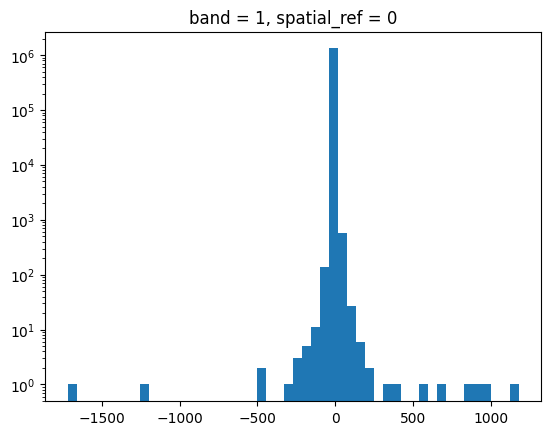

In [54]:
ut_mismatch_da.plot.hist(bins=50, log=True)

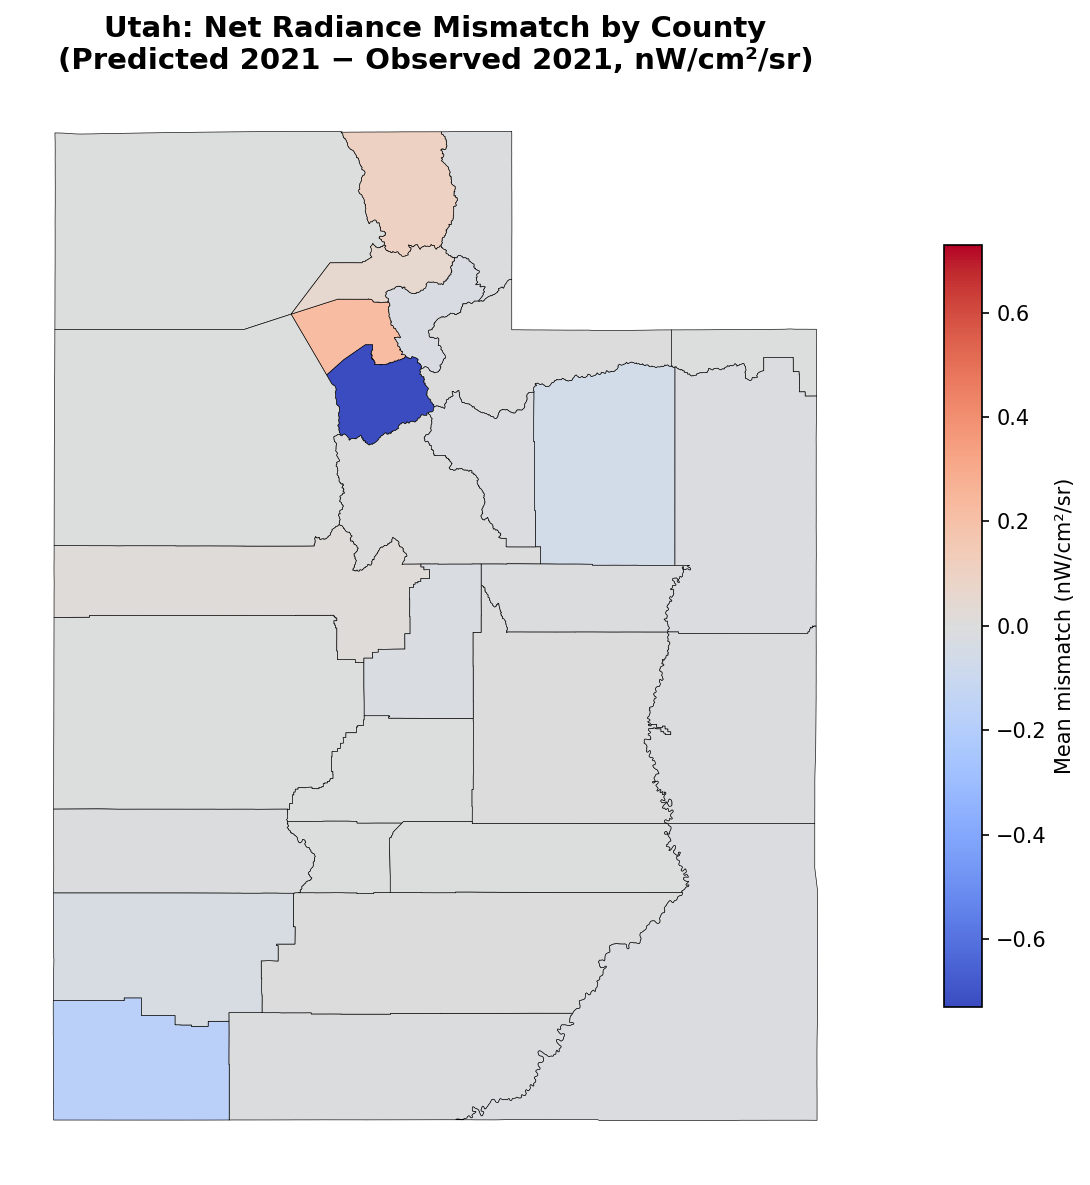

In [55]:
ut_counties = plot_county_choropleth(
    ut_mismatch_da,
    state_name="Utah",
    counties_shp=COUNTIES_SHP,
    state_fips='49',
)

In [56]:
print_mismatch_summary(ut_mismatch_da, ut_viirs_later_da, "Utah")


=== Utah – Radiance Mismatch (2021) ===
Total Observed Sum of Lights :      445,708.38 nW/cm²/sr
Net Mismatch (Predicted−Obs) :      -20,655.48 nW/cm²/sr (-4.63%)
Mean Absolute Error per pixel:           0.131 nW/cm²/sr

  Top 5 Most POSITIVE pixels (Predicted > Observed):
     lat       lon   mismatch
+39.8208 -111.8917 +1179.7087
+39.8167 -111.9000  +987.0898
+39.8208 -111.8958  +917.4191
+39.8125 -111.8958  +835.1699
+39.8208 -111.9000  +714.4458

  Top 5 Most NEGATIVE pixels (Predicted < Observed):
     lat       lon   mismatch
+39.8167 -111.8917 -1719.4310
+39.8167 -111.8958 -1247.5555
+39.8125 -111.8917  -499.7576
+39.8250 -111.8917  -474.1271
+40.7875 -111.9875  -278.0608


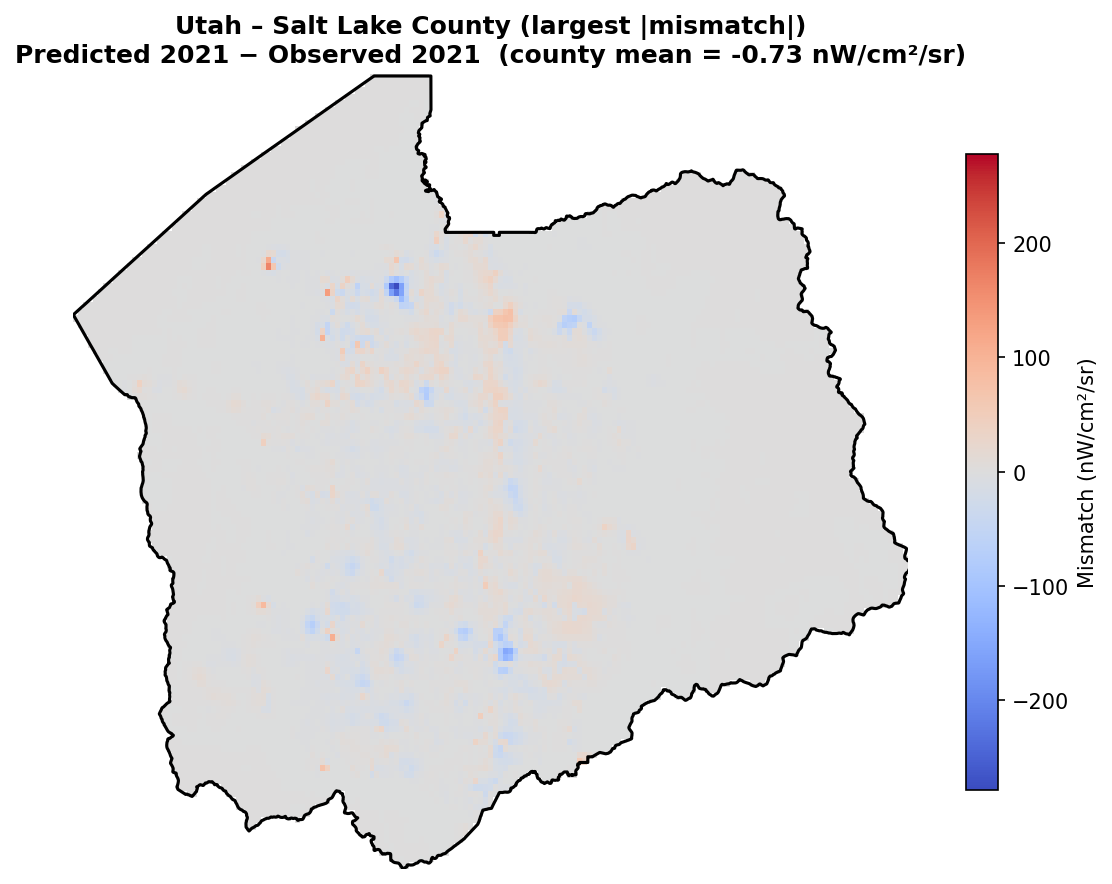

In [57]:
plot_biggest_mismatch_co(ut_mismatch_da, ut_counties, "Utah")

In [ ]:
ut_sq = run_sky_quality_analysis(
    "Utah",
    ut_viirs_older_da,
    ut_pred_later_da,
    ut_viirs_later_da,
    ut_state_gdf,
)


## Florida



  Running pipeline: Florida
[Florida] Loading older (2016) VIIRS radiance...
[Florida] Older grid shape: (1586, 1839)
[Florida] Loading impervious surfaces...
[Florida] Training set: 898,889 pixels, 9 features
[Florida] Training LightGBM...
[Florida] Predicting radiance at later date (2021)...


/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[Florida] Loading observed later (2021) VIIRS radiance...
[Florida] Pipeline complete.


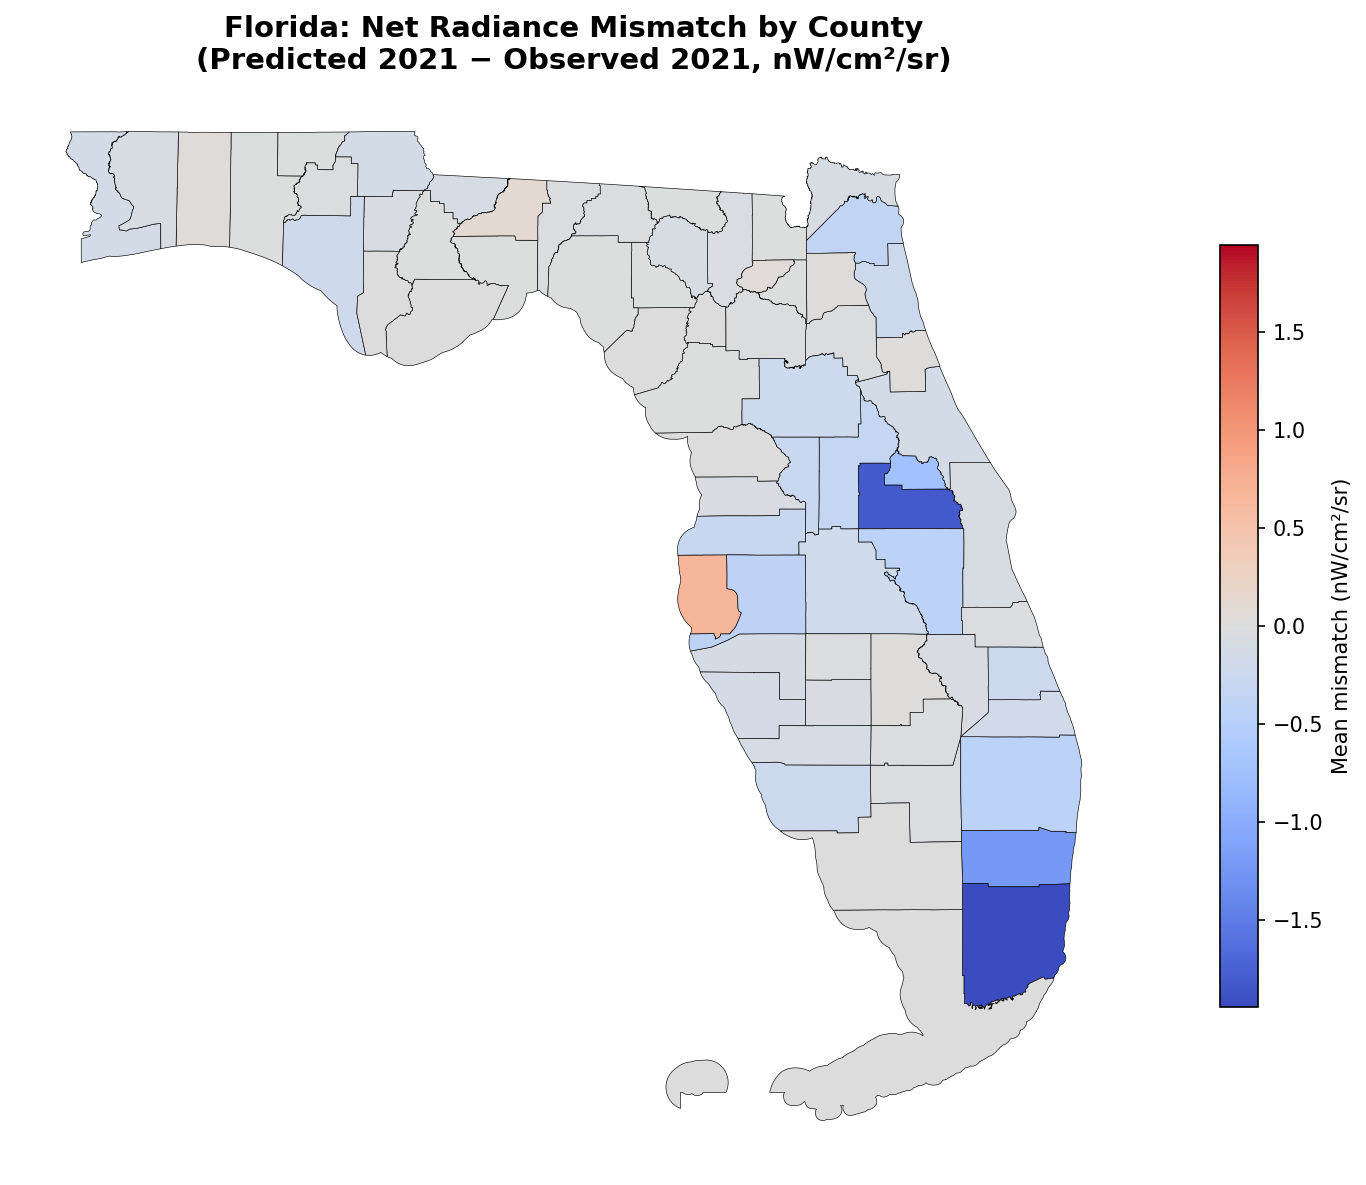

In [58]:
fl_mismatch_da, fl_viirs_later_da, fl_viirs_older_da, fl_pred_later_da, fl_state_gdf = run_state_pipeline("Florida")
fl_counties = plot_county_choropleth(
    fl_mismatch_da,
    state_name="Florida",
    counties_shp=COUNTIES_SHP,
    state_fips='12',
)


In [59]:
print_mismatch_summary(fl_mismatch_da, fl_viirs_later_da, "Florida")

=== Florida – Radiance Mismatch (2021) ===
Total Observed Sum of Lights :    2,746,893.75 nW/cm²/sr
Net Mismatch (Predicted−Obs) :     -197,791.36 nW/cm²/sr (-7.20%)
Mean Absolute Error per pixel:           0.696 nW/cm²/sr

  Top 5 Most POSITIVE pixels (Predicted > Observed):
     lat      lon  mismatch
+30.4000 -81.5375 +106.5650
+28.3375 -81.5583  +96.8625
+30.4417 -84.3000  +83.1570
+28.3708 -81.5250  +79.0489
+26.0625 -80.1250  +76.3883

  Top 5 Most NEGATIVE pixels (Predicted < Observed):
     lat      lon  mismatch
+27.6917 -82.3167 -258.4262
+27.6958 -82.3167 -215.4402
+28.6750 -81.4833 -159.0941
+28.4000 -81.5792 -155.6743
+27.6917 -82.3125 -151.5653


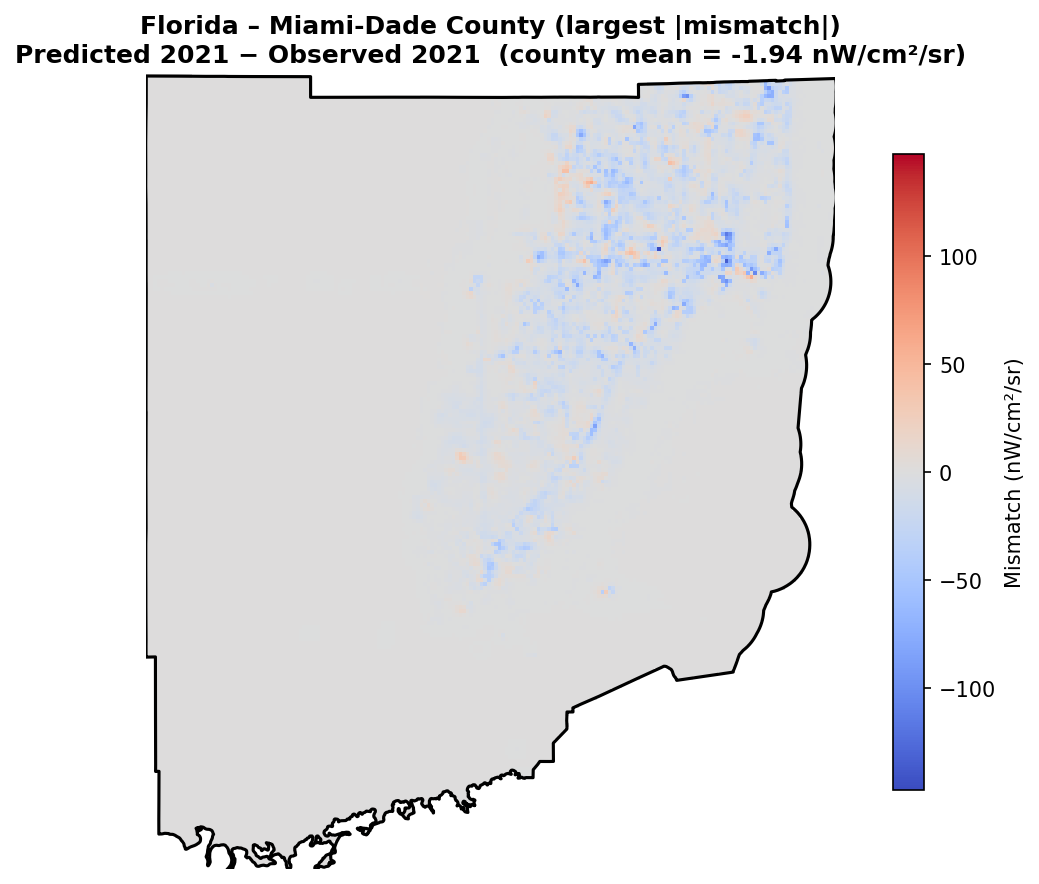

In [60]:
plot_biggest_mismatch_co(fl_mismatch_da, fl_counties, "Florida")

In [ ]:
fl_sq = run_sky_quality_analysis(
    "Florida",
    fl_viirs_older_da,
    fl_pred_later_da,
    fl_viirs_later_da,
    fl_state_gdf,
)
